In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/Assignment2/Q2_Diabetes"
os.makedirs(BASE, exist_ok=True)
os.makedirs(os.path.join(BASE,"data"), exist_ok=True)
os.makedirs(os.path.join(BASE,"figures"), exist_ok=True)
os.makedirs(os.path.join(BASE,"outputs"), exist_ok=True)
os.makedirs(os.path.join(BASE,"reports"), exist_ok=True)

print("Base folder created:", BASE)

Mounted at /content/drive
Base folder created: /content/drive/MyDrive/Assignment2/Q2_Diabetes


In [2]:
 # Run this cell and upload diabetes.csv via the file chooser.
from google.colab import files
import shutil, os

print("Upload diabetes.csv now...")
uploaded = files.upload()   # click Choose files
for fn in uploaded.keys():
    dest = os.path.join(BASE, "data", fn)
    shutil.move(fn, dest)
    print("Saved uploaded file to:", dest)

DATA_CSV = dest  # path to dataset
print("DATA_CSV =", DATA_CSV)

Upload diabetes.csv now...


Saving diabetes.csv to diabetes.csv
Saved uploaded file to: /content/drive/MyDrive/Assignment2/Q2_Diabetes/data/diabetes.csv
DATA_CSV = /content/drive/MyDrive/Assignment2/Q2_Diabetes/data/diabetes.csv


In [3]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set(style="whitegrid")

df = pd.read_csv(DATA_CSV)
print("Shape:", df.shape)
display(df.head())
df.info()
# Save a copy of the raw data
df.to_csv(os.path.join(BASE,"data","diabetes_raw_copy.csv"), index=False)

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
SEED = 42
np.random.seed(SEED)

sample25 = df.sample(n=25, random_state=SEED)

# population stats
pop_mean_glucose = df['Glucose'].mean()
pop_max_glucose  = df['Glucose'].max()

# sample stats
sample_mean_glucose = sample25['Glucose'].mean()
sample_max_glucose  = sample25['Glucose'].max()

print(f"Population mean Glucose = {pop_mean_glucose:.3f}, max = {pop_max_glucose}")
print(f"Sample (n=25) mean Glucose = {sample_mean_glucose:.3f}, max = {sample_max_glucose}")

# save sample
sample25.to_csv(os.path.join(BASE,"data","sample25_glucose.csv"), index=False)

Population mean Glucose = 120.895, max = 199
Sample (n=25) mean Glucose = 116.640, max = 183


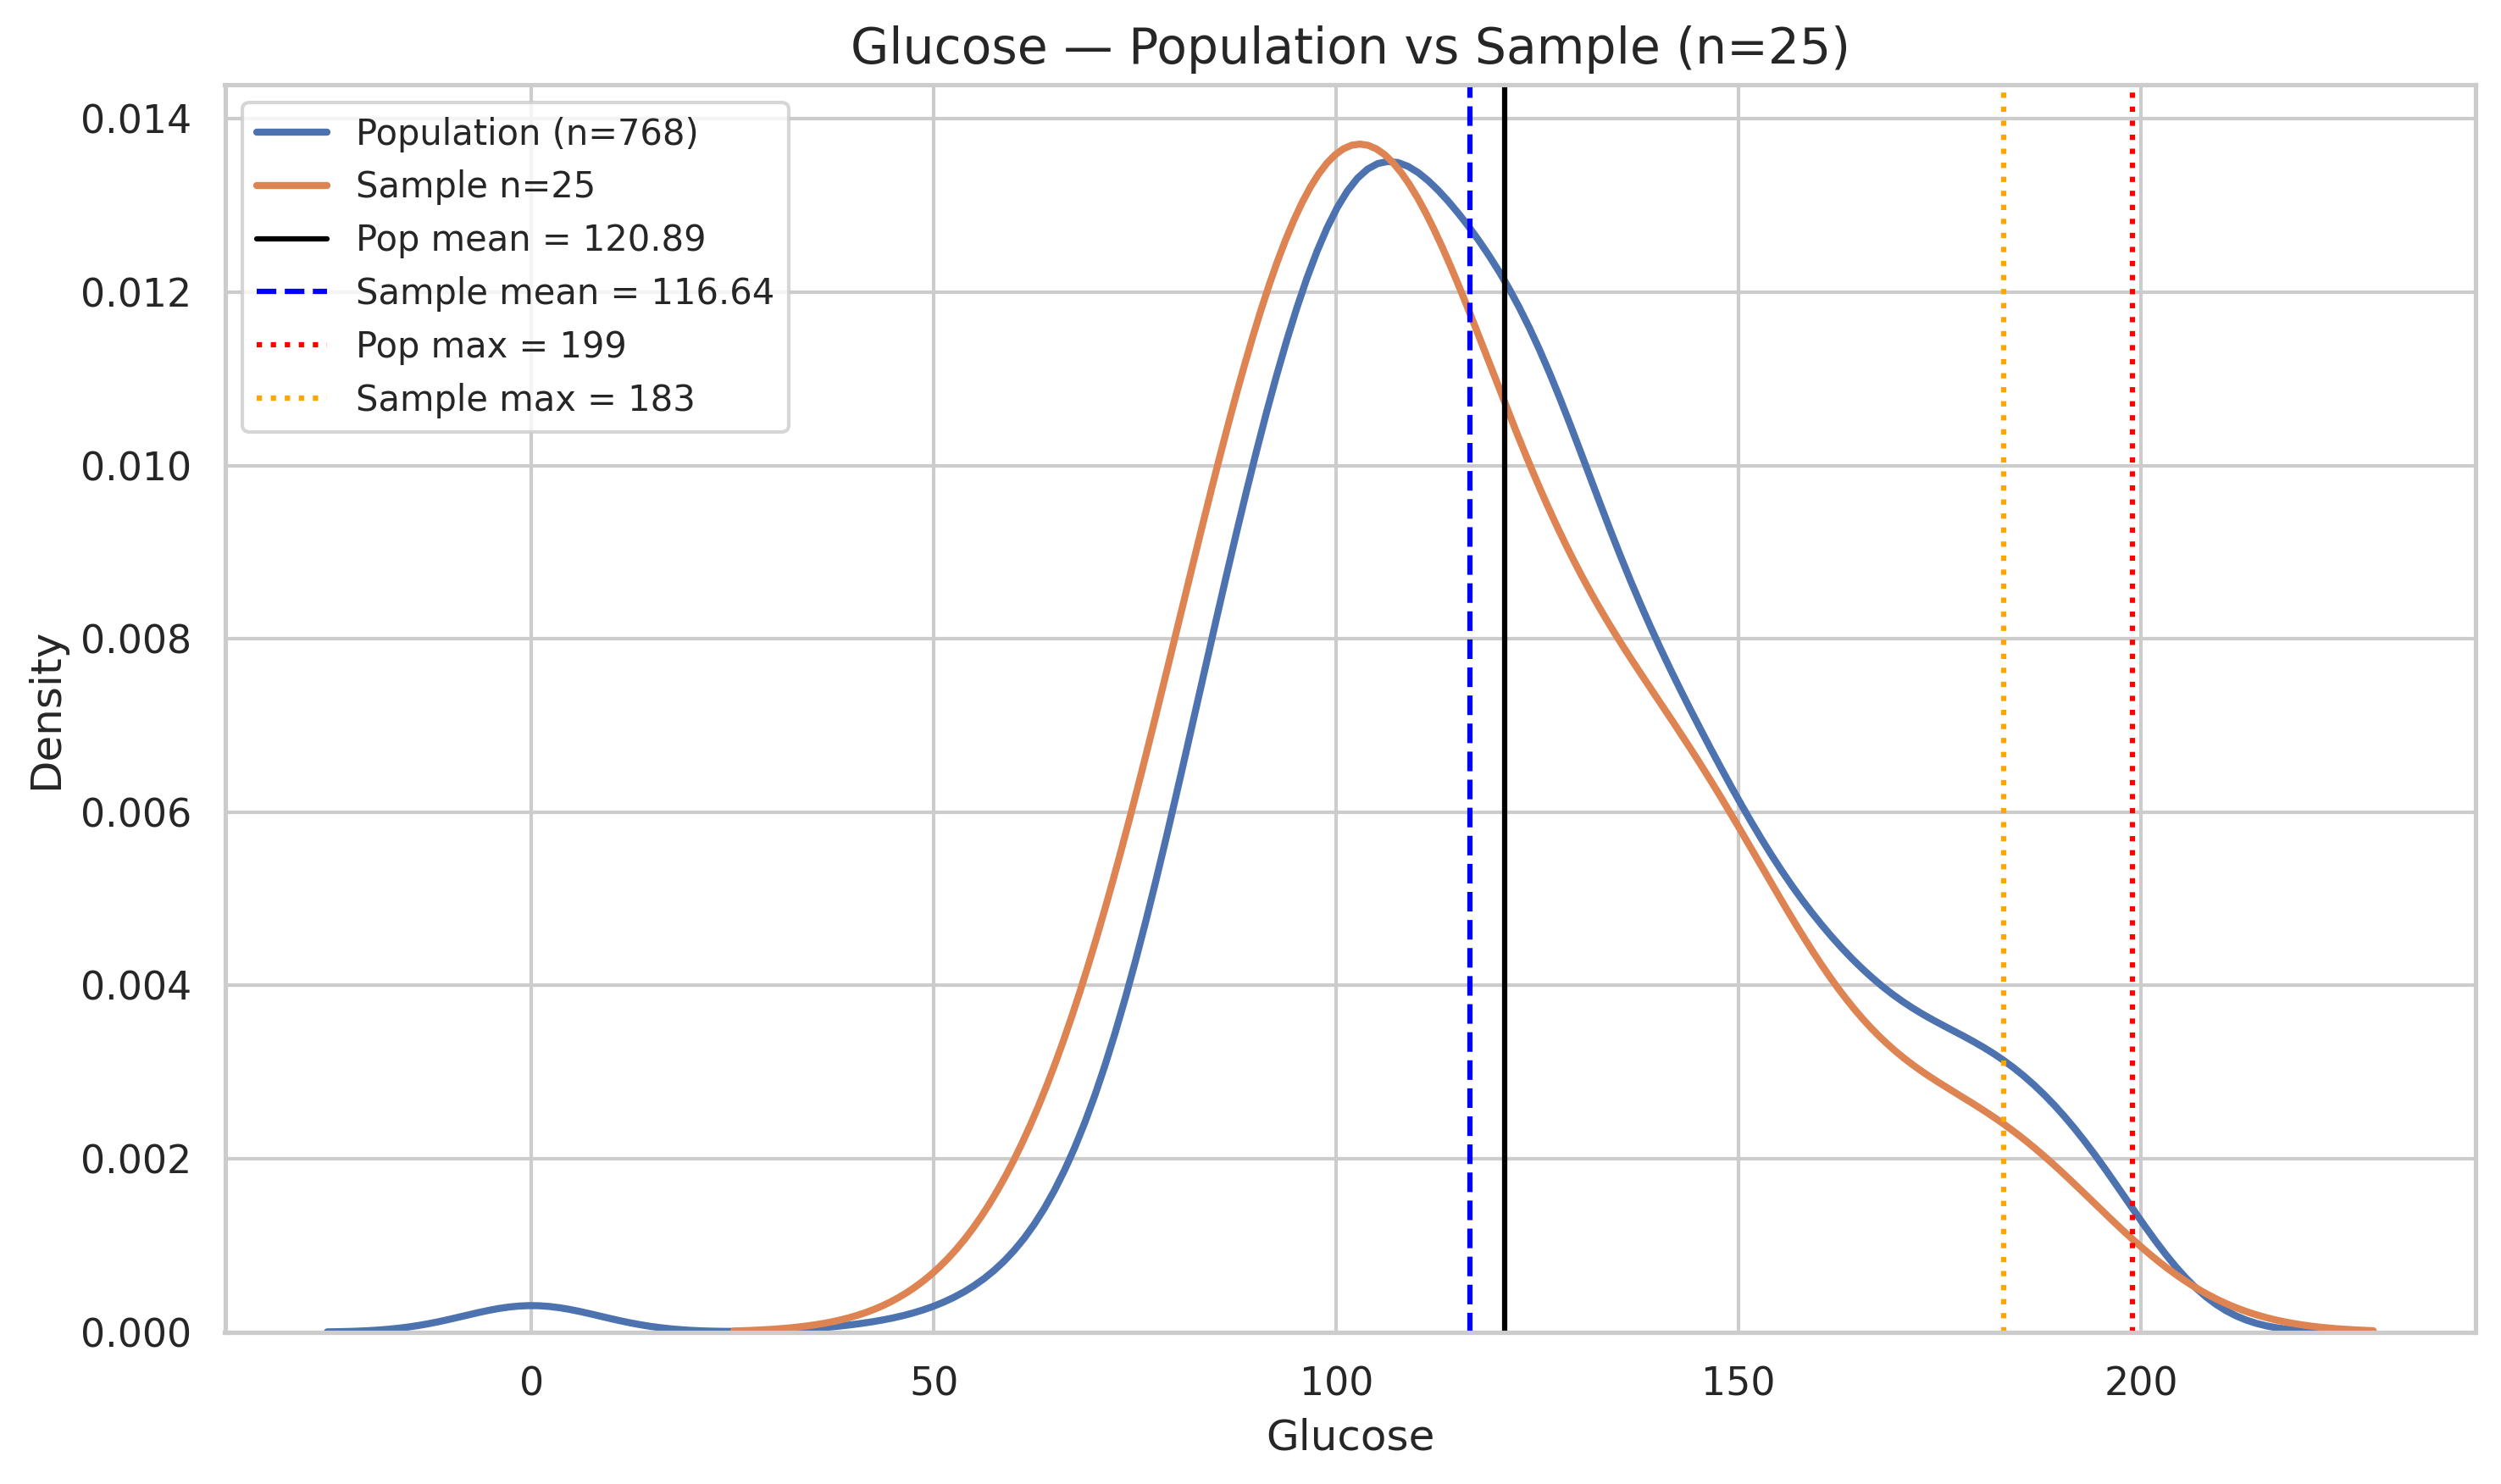

/tmp/ipython-input-258706719.py:22: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=[df['Glucose'], sample25['Glucose']], palette=["#7fb3d5","#f7b7a3"])


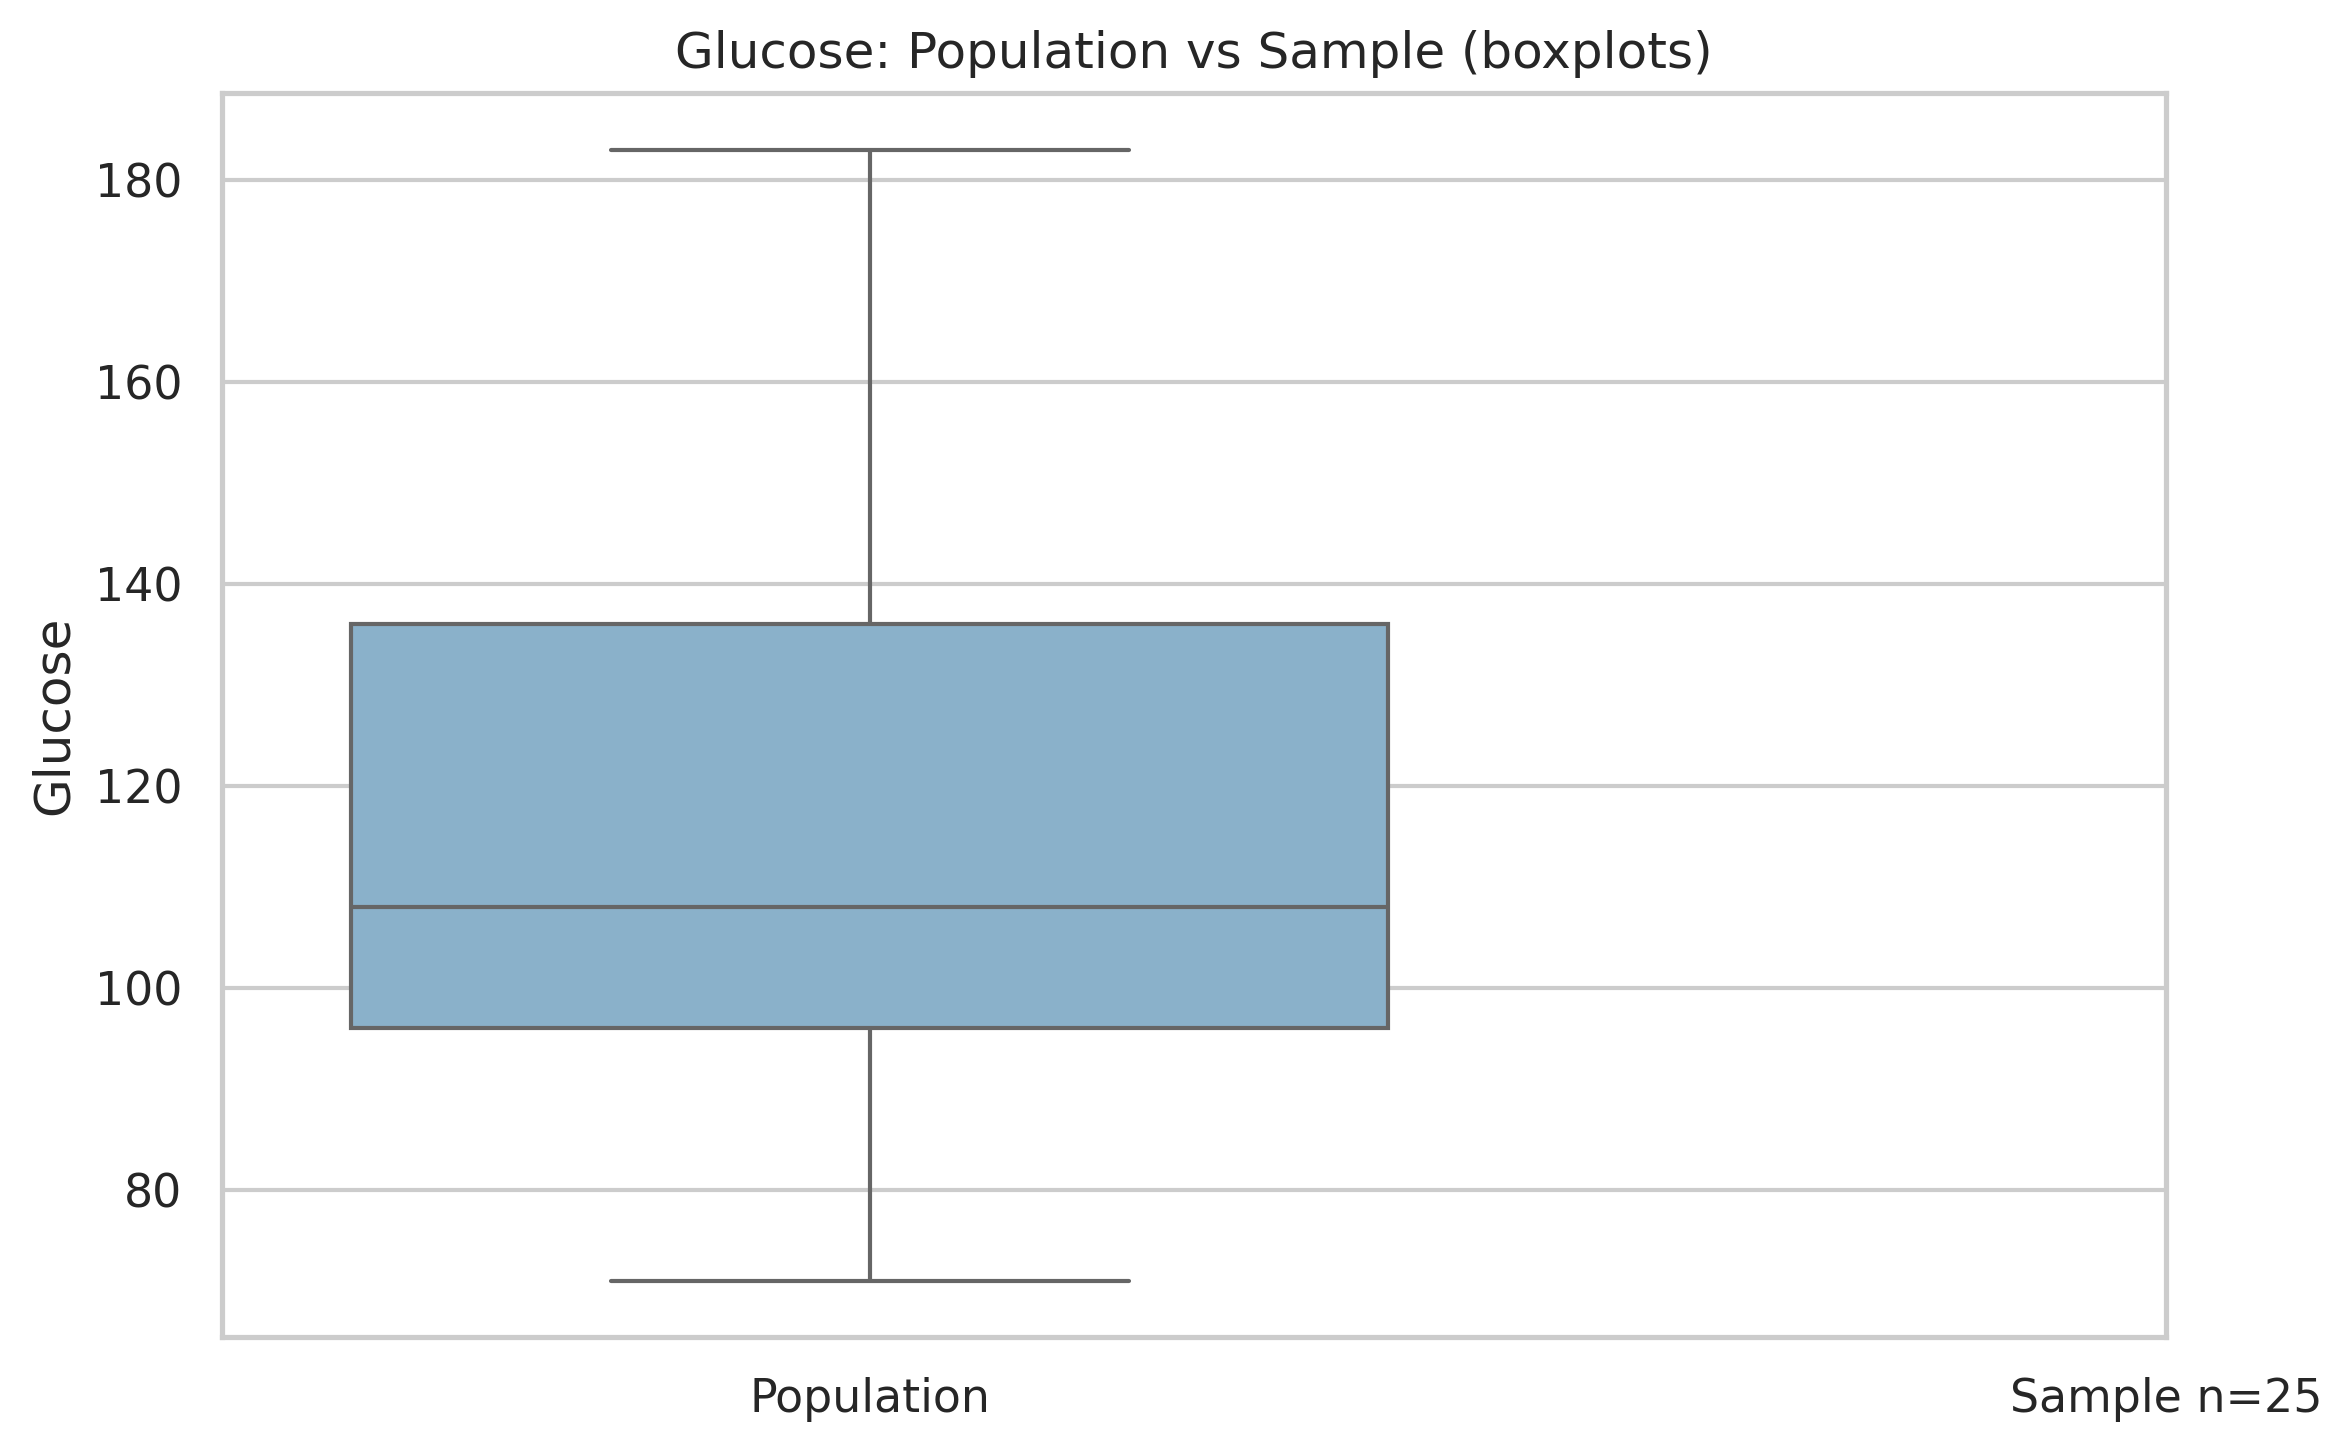

In [5]:
plt.figure(figsize=(10,6), dpi=300)
# KDEs
sns.kdeplot(df['Glucose'], label='Population (n={})'.format(len(df)), linewidth=2)
sns.kdeplot(sample25['Glucose'], label='Sample n=25', linewidth=2)

# Vertical lines for means and max
plt.axvline(pop_mean_glucose, color='black', linestyle='-', label=f'Pop mean = {pop_mean_glucose:.2f}')
plt.axvline(sample_mean_glucose, color='blue', linestyle='--', label=f'Sample mean = {sample_mean_glucose:.2f}')
plt.axvline(pop_max_glucose, color='red', linestyle=':', label=f'Pop max = {pop_max_glucose:.0f}')
plt.axvline(sample_max_glucose, color='orange', linestyle=':', label=f'Sample max = {sample_max_glucose:.0f}')

plt.title("Glucose — Population vs Sample (n=25)", fontsize=14)
plt.xlabel("Glucose")
plt.ylabel("Density")
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(BASE,"figures","Q2a_glucose_kde_compare.png"), dpi=300)
plt.show()

# Boxplots side-by-side for quick view
plt.figure(figsize=(8,5), dpi=300)
sns.boxplot(data=[df['Glucose'], sample25['Glucose']], palette=["#7fb3d5","#f7b7a3"])
plt.xticks([0,1], ['Population','Sample n=25'])
plt.title("Glucose: Population vs Sample (boxplots)")
plt.ylabel("Glucose")
plt.tight_layout()
plt.savefig(os.path.join(BASE,"figures","Q2a_glucose_box_compare.png"), dpi=300)
plt.show()

For Glucose, the population mean is **{pop_mean_glucose:.2f}** and  
the population maximum is **{pop_max_glucose:.0f}**.

In [7]:
pop_bmi_p98 = df['BMI'].quantile(0.98)
sample_bmi_p98 = sample25['BMI'].quantile(0.98)

print(f"Population 98th percentile BMI = {pop_bmi_p98:.3f}")
print(f"Sample (n=25) 98th percentile BMI = {sample_bmi_p98:.3f}")

Population 98th percentile BMI = 47.526
Sample (n=25) 98th percentile BMI = 40.248


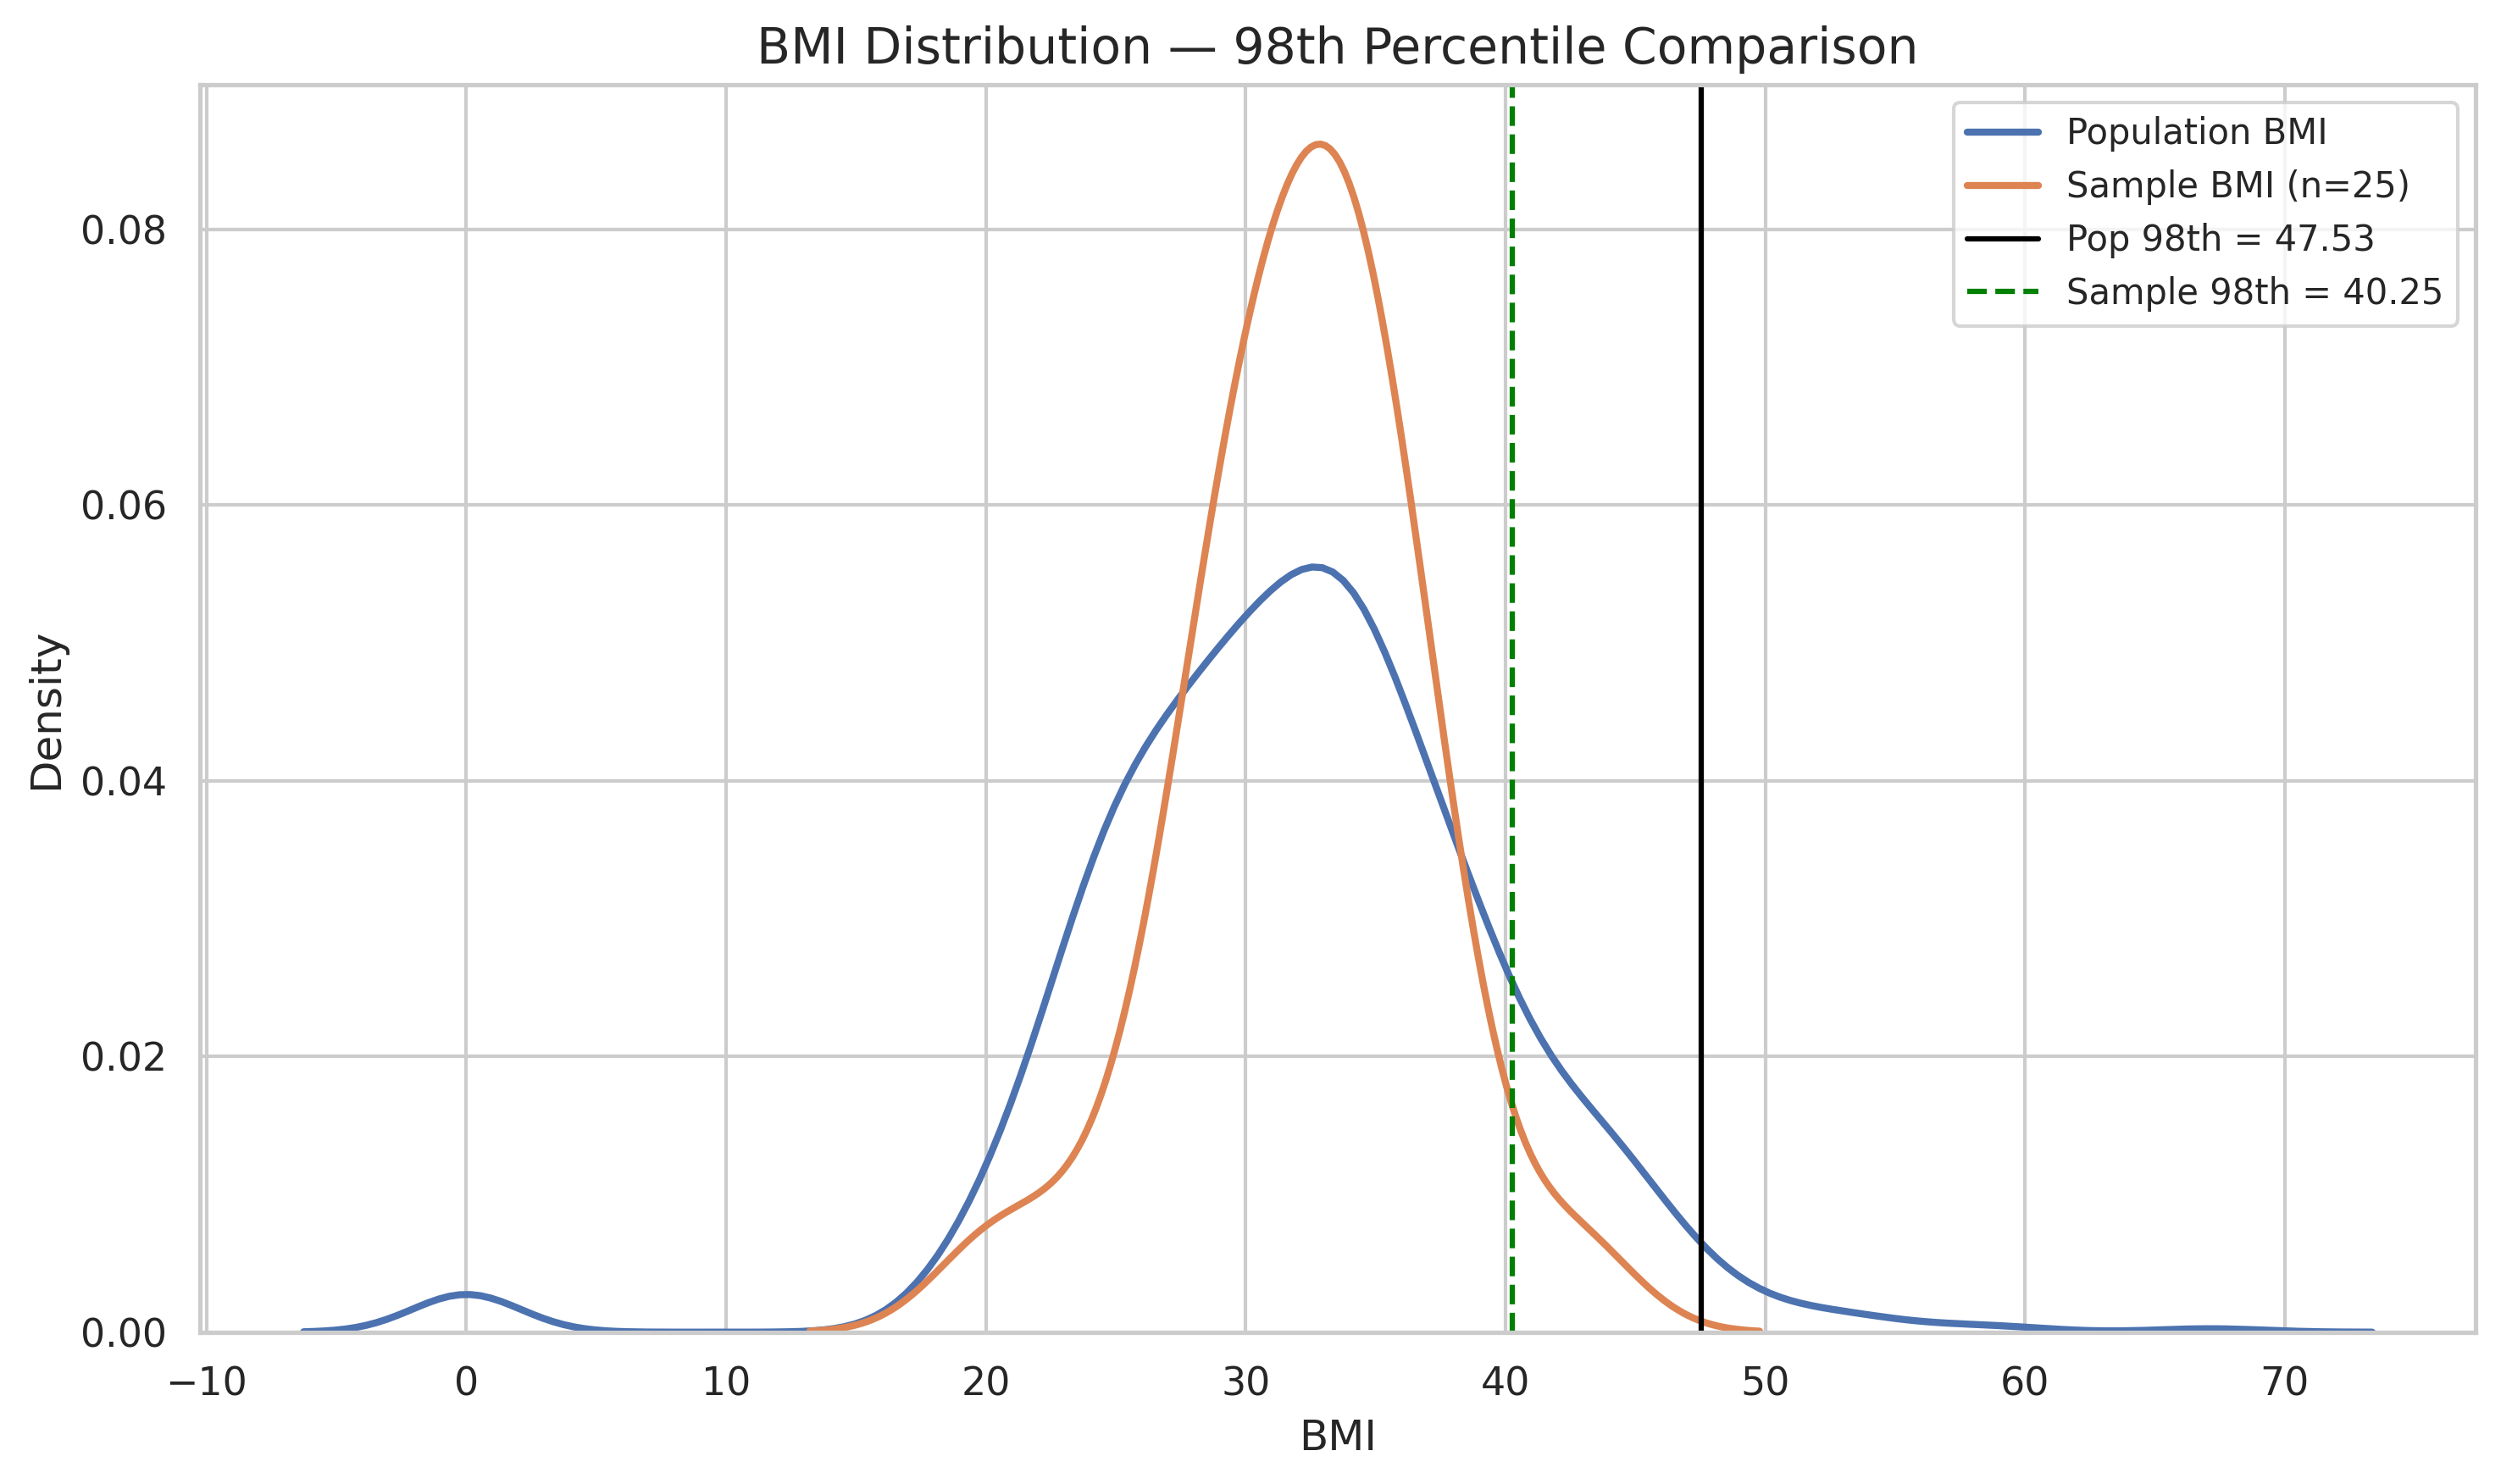

In [8]:
plt.figure(figsize=(10,6), dpi=300)
sns.kdeplot(df['BMI'], label='Population BMI', linewidth=2)
sns.kdeplot(sample25['BMI'], label='Sample BMI (n=25)', linewidth=2)
plt.axvline(pop_bmi_p98, color='black', linestyle='-', label=f'Pop 98th = {pop_bmi_p98:.2f}')
plt.axvline(sample_bmi_p98, color='green', linestyle='--', label=f'Sample 98th = {sample_bmi_p98:.2f}')
plt.title("BMI Distribution — 98th Percentile Comparison", fontsize=14)
plt.xlabel("BMI")
plt.ylabel("Density")
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(BASE,"figures","Q2b_bmi_p98_compare.png"), dpi=300)
plt.show()

The 98th percentile of BMI in the population is {pop_bmi_p98:.2f}, while in the sample it is {sample_bmi_p98:.2f}.
Because the sample is small (n=25), the extreme percentile estimates can differ substantially from the population.
The KDE plot shows the sample's tail behavior relative to the population.


In [10]:
R = 500      # number of bootstrap samples
m = 150      # size of each bootstrap sample
SEED_BOOT = 12345
rng = np.random.default_rng(SEED_BOOT)

bp_means = np.empty(R)
bp_stds  = np.empty(R)
bp_p98s  = np.empty(R)

# Convert to numpy array for speed
bp_pop = df['BloodPressure'].values
n_pop = len(bp_pop)

for i in range(R):
    # draw with replacement using rng.choice
    sample_idx = rng.choice(n_pop, size=m, replace=True)
    boot = bp_pop[sample_idx]
    bp_means[i] = boot.mean()
    bp_stds[i]  = boot.std(ddof=1)
    bp_p98s[i]  = np.percentile(boot, 98)

# Save bootstrap arrays
import pandas as pd
pd.DataFrame({'bp_mean':bp_means, 'bp_std':bp_stds, 'bp_98':bp_p98s}).to_csv(os.path.join(BASE,"outputs","bootstrap_bp_stats.csv"), index=False)

# Population stats
pop_bp_mean = float(df['BloodPressure'].mean())
pop_bp_std  = float(df['BloodPressure'].std(ddof=1))
pop_bp_p98  = float(np.percentile(bp_pop, 98))

print("Population BloodPressure stats:", pop_bp_mean, pop_bp_std, pop_bp_p98)
print("Bootstrap averages:", bp_means.mean(), bp_stds.mean(), bp_p98s.mean())

Population BloodPressure stats: 69.10546875 19.355807170644777 99.31999999999994
Bootstrap averages: 69.13641333333334 19.185703753244432 98.12488000000002


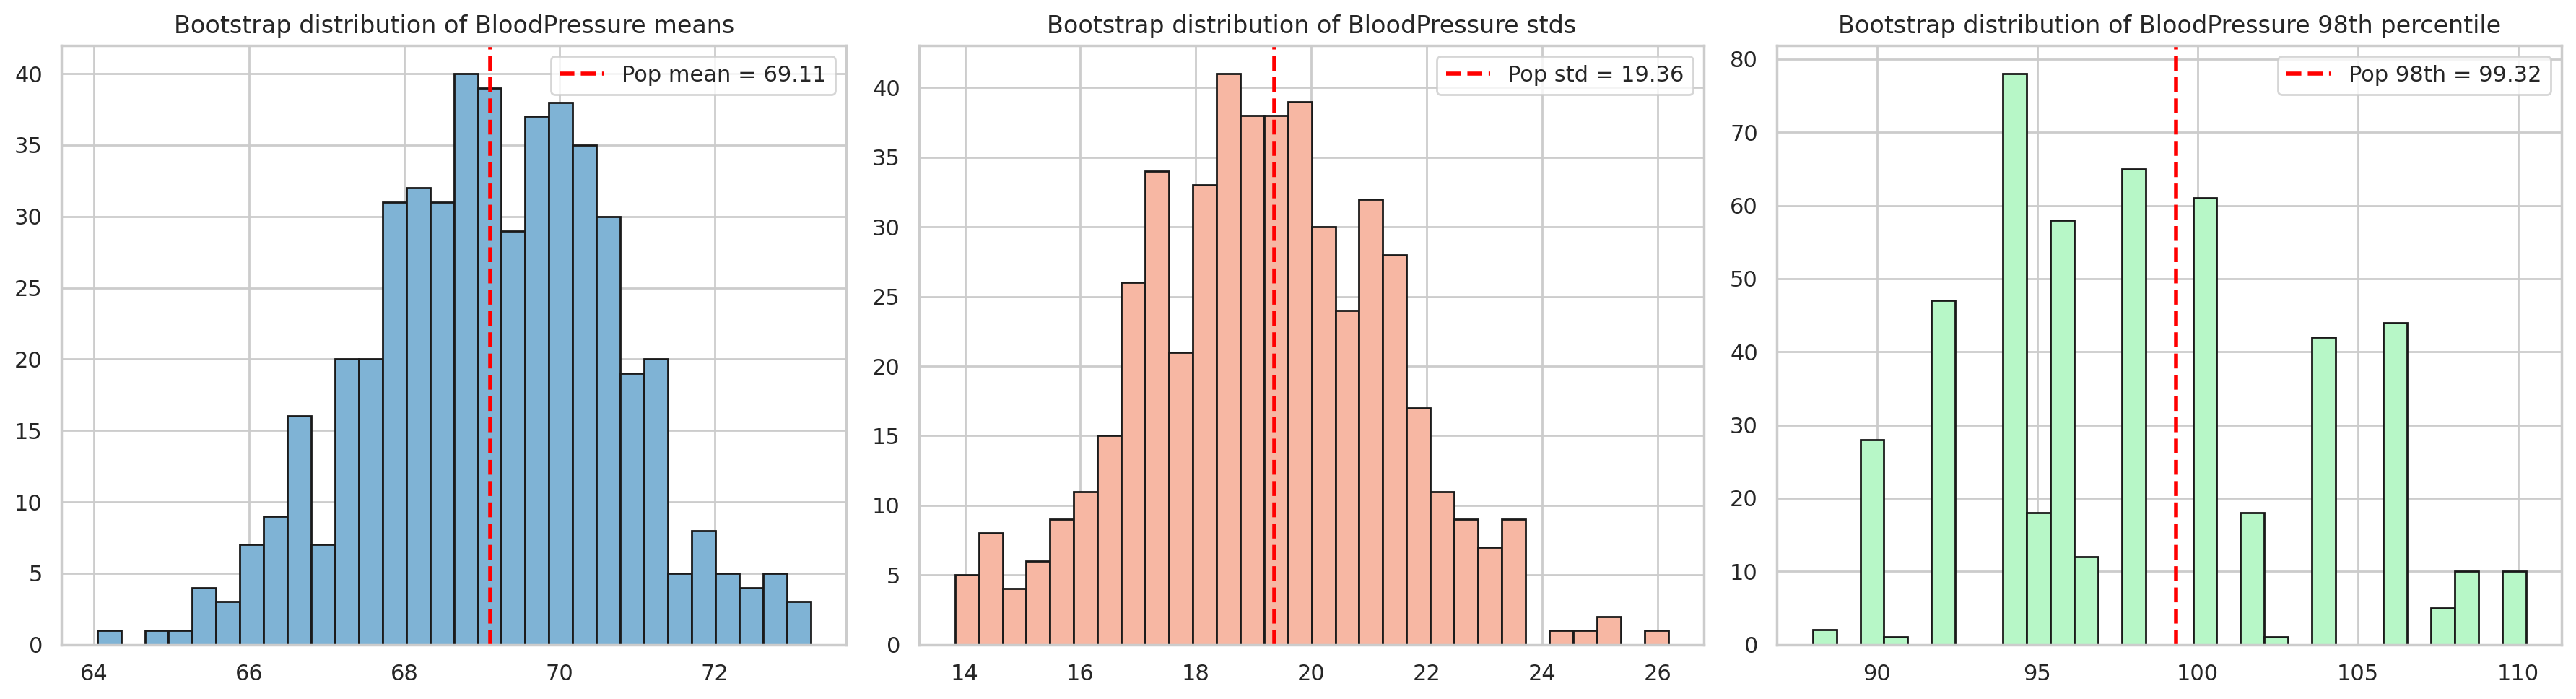

In [11]:
fig, axes = plt.subplots(1,3, figsize=(18,5), dpi=200)

axes[0].hist(bp_means, bins=30, color="#7fb3d5", edgecolor="k")
axes[0].axvline(pop_bp_mean, color='red', linestyle='--', linewidth=2, label=f'Pop mean = {pop_bp_mean:.2f}')
axes[0].set_title("Bootstrap distribution of BloodPressure means")
axes[0].legend()

axes[1].hist(bp_stds, bins=30, color="#f7b7a3", edgecolor="k")
axes[1].axvline(pop_bp_std, color='red', linestyle='--', linewidth=2, label=f'Pop std = {pop_bp_std:.2f}')
axes[1].set_title("Bootstrap distribution of BloodPressure stds")
axes[1].legend()

axes[2].hist(bp_p98s, bins=30, color="#b7f7c7", edgecolor="k")
axes[2].axvline(pop_bp_p98, color='red', linestyle='--', linewidth=2, label=f'Pop 98th = {pop_bp_p98:.2f}')
axes[2].set_title("Bootstrap distribution of BloodPressure 98th percentile")
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(BASE,"figures","Q2c_bootstrap_bp_stats.png"), dpi=300)
plt.show()

In [12]:
summary = {
    'stat': ['mean','std','98th_pct'],
    'population': [pop_bp_mean, pop_bp_std, pop_bp_p98],
    'bootstrap_avg': [bp_means.mean(), bp_stds.mean(), bp_p98s.mean()],
    'bootstrap_std_of_estimates': [bp_means.std(ddof=1), bp_stds.std(ddof=1), bp_p98s.std(ddof=1)]
}
summary_df = pd.DataFrame(summary)
summary_df.to_csv(os.path.join(BASE,"reports","bootstrap_summary_comparison.csv"), index=False)
display(summary_df)

,stat,population,bootstrap_avg,bootstrap_std_of_estimates
0,mean,69.105469,69.136413,1.564862
1,std,19.355807,19.185704,2.136524
2,98th_pct,99.320000,98.124880,5.144101


In [13]:
# findings.md (brief)
with open(os.path.join(BASE,"reports","findings.md"), "w") as f:
    f.write("# Q2 Diabetes Analysis Findings\n\n")
    f.write("## Part (a) — Glucose sample vs population\n")
    f.write(f"- Population mean Glucose = {pop_mean_glucose:.3f}; population max = {pop_max_glucose}\n")
    f.write(f"- Sample (n=25, seed={SEED}) mean Glucose = {sample_mean_glucose:.3f}; sample max = {sample_max_glucose}\n")
    f.write("  - See figures/Q2a_glucose_kde_compare.png and Q2a_glucose_box_compare.png.\n\n")
    f.write("## Part (b) — BMI 98th percentile\n")
    f.write(f"- Population 98th percentile BMI = {pop_bmi_p98:.3f}\n")
    f.write(f"- Sample 98th percentile BMI = {sample_bmi_p98:.3f}\n")
    f.write("  - See figures/Q2b_bmi_p98_compare.png.\n\n")
    f.write("## Part (c) — Bootstrap on BloodPressure (R=500, m=150)\n")
    f.write(f"- Population mean/std/98th = {pop_bp_mean:.3f}, {pop_bp_std:.3f}, {pop_bp_p98:.3f}\n")
    f.write(f"- Bootstrap average mean/std/98th = {bp_means.mean():.3f}, {bp_stds.mean():.3f}, {bp_p98s.mean():.3f}\n")
    f.write("  - See figures/Q2c_bootstrap_bp_stats.png and reports/bootstrap_summary_comparison.csv\n")

# what_I_have_done.txt (normal plain text)
what_text = """Steps performed in Diabetes analysis (Q2):

1. Mounted Google Drive and created folders (data, figures, outputs, reports).
2. Uploaded diabetes.csv manually and saved a copy.
3. Set random seed (seed=42) and drew a random sample of n=25. Computed sample mean and max for Glucose and compared to population statistics; saved KDE and boxplots.
4. Computed 98th percentile of BMI for sample and population; saved comparison plot.
5. Performed bootstrap sampling with R=500, m=150 (replace=True) on BloodPressure. Collected bootstrap distributions for mean, std, and 98th percentile. Saved bootstrap CSV and plots.
6. Saved summary comparisons to reports/bootstrap_summary_comparison.csv and written findings.md.
"""
with open(os.path.join(BASE,"what_I_have_done.txt"), "w") as f:
    f.write(what_text)

print("Saved findings.md and what_I_have_done.txt to reports.")

Saved findings.md and what_I_have_done.txt to reports.


In [14]:
import shutil
zip_out = os.path.join("/content/drive/MyDrive/Assignment2", "Q2_Diabetes.zip")
shutil.make_archive(zip_out.replace('.zip',''), 'zip', root_dir=BASE)
print("Created zip:", zip_out)

Created zip: /content/drive/MyDrive/Assignment2/Q2_Diabetes.zip
